In [ ]:
# Step 1: Verify GPU and environment setup
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs: 1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step 2: Explore dataset structure
import os

# Update this path to where your dataset folder is in Colab runtime
DATASET_PATH = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset'  # adjust if your folder is nested differently

train_dir = os.path.join(DATASET_PATH, 'Train')
test_dir  = os.path.join(DATASET_PATH, 'Test')

# Check folders exist
print("Train folder exists:", os.path.exists(train_dir))
print("Test folder exists:", os.path.exists(test_dir))

# List classes
train_classes = sorted(os.listdir(train_dir))
print(f"\nNumber of classes: {len(train_classes)}")
print(f"Class labels: {train_classes}")

# Count images per class
print("\n--- Images per class (Train) ---")
total_train = 0
for cls in train_classes:
    cls_path = os.path.join(train_dir, cls)
    count = len(os.listdir(cls_path))
    total_train += count
    print(f"  Class {cls}: {count} images")

print(f"\nTotal training images: {total_train}")

# Test set
total_test = len(os.listdir(test_dir))
print(f"Total test images: {total_test}")

Train folder exists: True
Test folder exists: True

Number of classes: 38
Class labels: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '4', '5', '6', '7', '8', '9']

--- Images per class (Train) ---
  Class 0: 286 images
  Class 1: 287 images
  Class 10: 291 images
  Class 11: 284 images
  Class 12: 277 images
  Class 13: 295 images
  Class 14: 270 images
  Class 15: 287 images
  Class 16: 291 images
  Class 17: 286 images
  Class 18: 303 images
  Class 19: 288 images
  Class 2: 291 images
  Class 20: 286 images
  Class 21: 286 images
  Class 22: 309 images
  Class 23: 285 images
  Class 24: 290 images
  Class 25: 302 images
  Class 26: 285 images
  Class 27: 286 images
  Class 28: 284 images
  Class 29: 285 images
  Class 3: 279 images
  Class 30: 301 images
  Class 31: 288 images
  Class 32: 281 images
  Class 33: 288 images
  Class 34: 283 ima

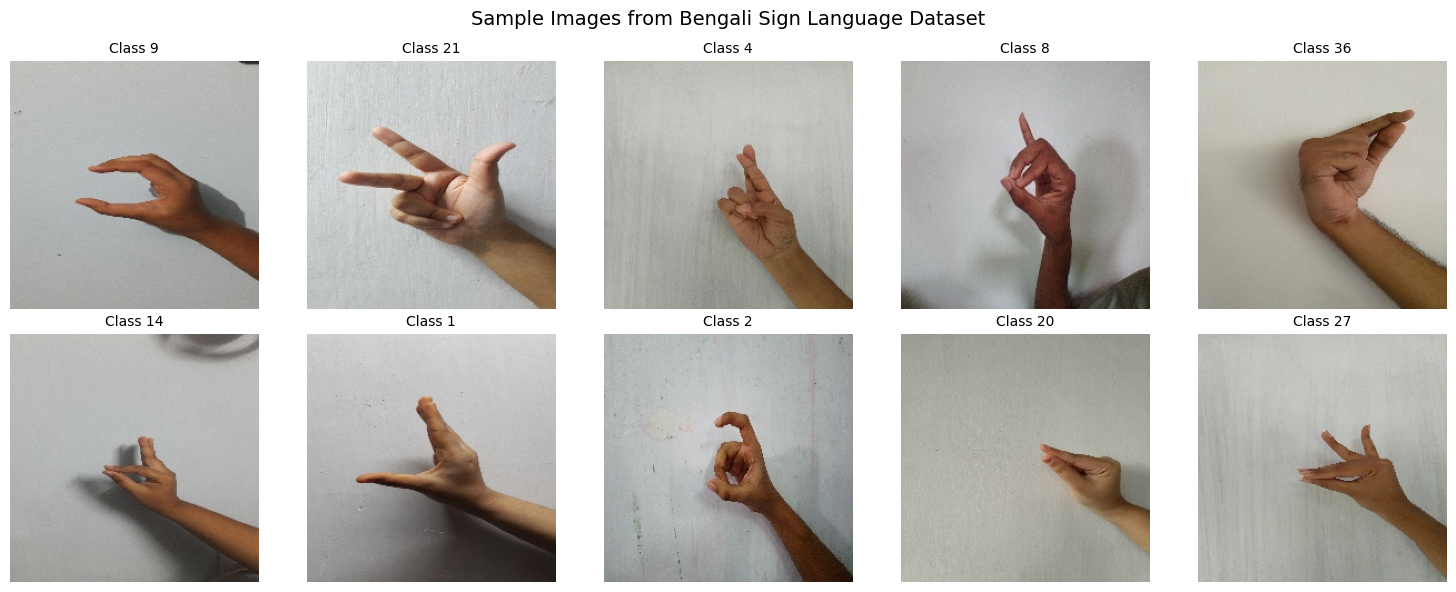

Sample image shape: (224, 224, 3)
Pixel value range: min=11, max=225


In [ ]:
# Step 3: Visualize sample images from the dataset
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

train_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Train'
classes = sorted(os.listdir(train_dir))

# Pick 10 random classes and show 1 sample each
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Bengali Sign Language Dataset', fontsize=14)

sampled_classes = random.sample(classes, 10)

for ax, cls in zip(axes.flatten(), sampled_classes):
    cls_path = os.path.join(train_dir, cls)
    img_file = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_file)
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(f'Class {cls}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Also print image shape info
sample_cls = classes[0]
sample_img_path = os.path.join(train_dir, sample_cls, os.listdir(os.path.join(train_dir, sample_cls))[0])
sample_img = mpimg.imread(sample_img_path)
print(f"Sample image shape: {sample_img.shape}")
print(f"Pixel value range: min={sample_img.min()}, max={sample_img.max()}")

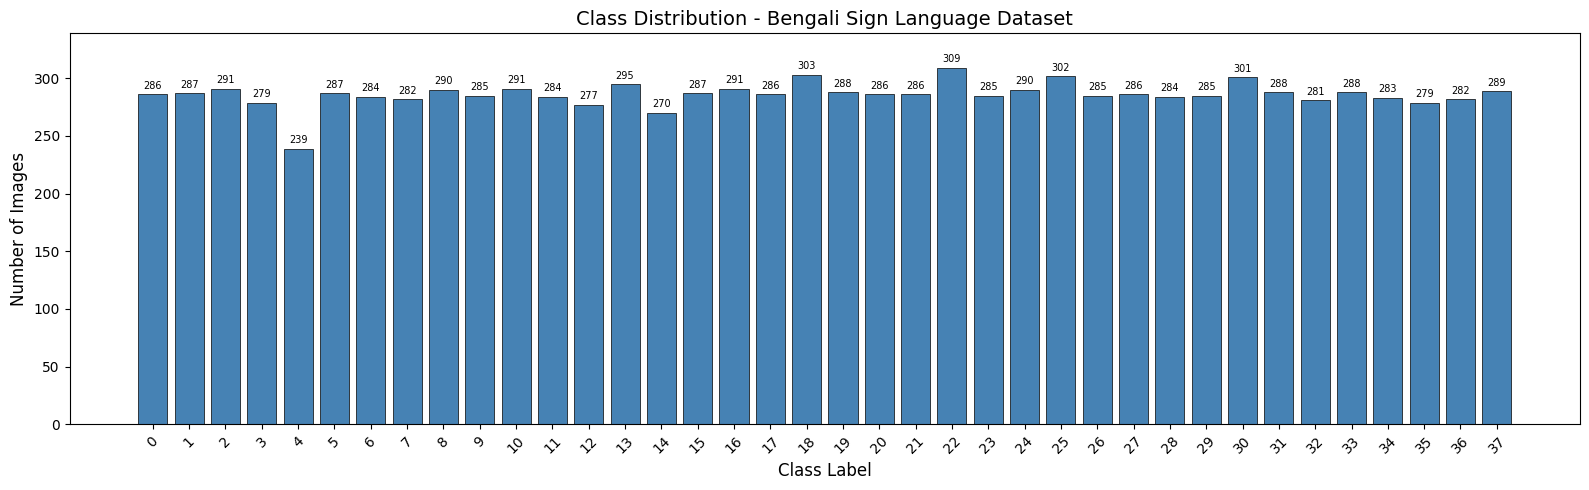

Min images in a class: 239 (Class 4)
Max images in a class: 309 (Class 22)
Average images per class: 286.1


In [ ]:
# Step 4: Class distribution visualization
import matplotlib.pyplot as plt
import os

train_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Train'
classes = sorted(os.listdir(train_dir), key=lambda x: int(x))

class_counts = []
for cls in classes:
    count = len(os.listdir(os.path.join(train_dir, cls)))
    class_counts.append(count)

plt.figure(figsize=(16, 5))
bars = plt.bar(classes, class_counts, color='steelblue', edgecolor='black', linewidth=0.5)
plt.title('Class Distribution - Bengali Sign Language Dataset', fontsize=14)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, max(class_counts) + 30)

# Add value labels on top of bars
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(count), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print(f"Min images in a class: {min(class_counts)} (Class {classes[class_counts.index(min(class_counts))]})")
print(f"Max images in a class: {max(class_counts)} (Class {classes[class_counts.index(max(class_counts))]})")
print(f"Average images per class: {sum(class_counts)/len(class_counts):.1f}")

In [ ]:
# Step 5: Data Preprocessing and Generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Directories
train_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Train'
test_dir  = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Test'

# Image settings
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 38

# ── Train generator: normalize + augmentation ──────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,            # normalize to [0, 1]
    validation_split=0.2,      # 80/20 split
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# ── Validation generator: only normalize (no augmentation) ─────────────
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# ── Load Train set ──────────────────────────────────────────────────────
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# ── Load Validation set ─────────────────────────────────────────────────
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"\nTraining samples:   {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Number of classes:  {train_generator.num_classes}")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Steps per epoch:    {train_generator.samples // BATCH_SIZE}")


Found 8711 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.

Training samples:   8711
Validation samples: 2160
Number of classes:  38
Batch size:         32
Steps per epoch:    272


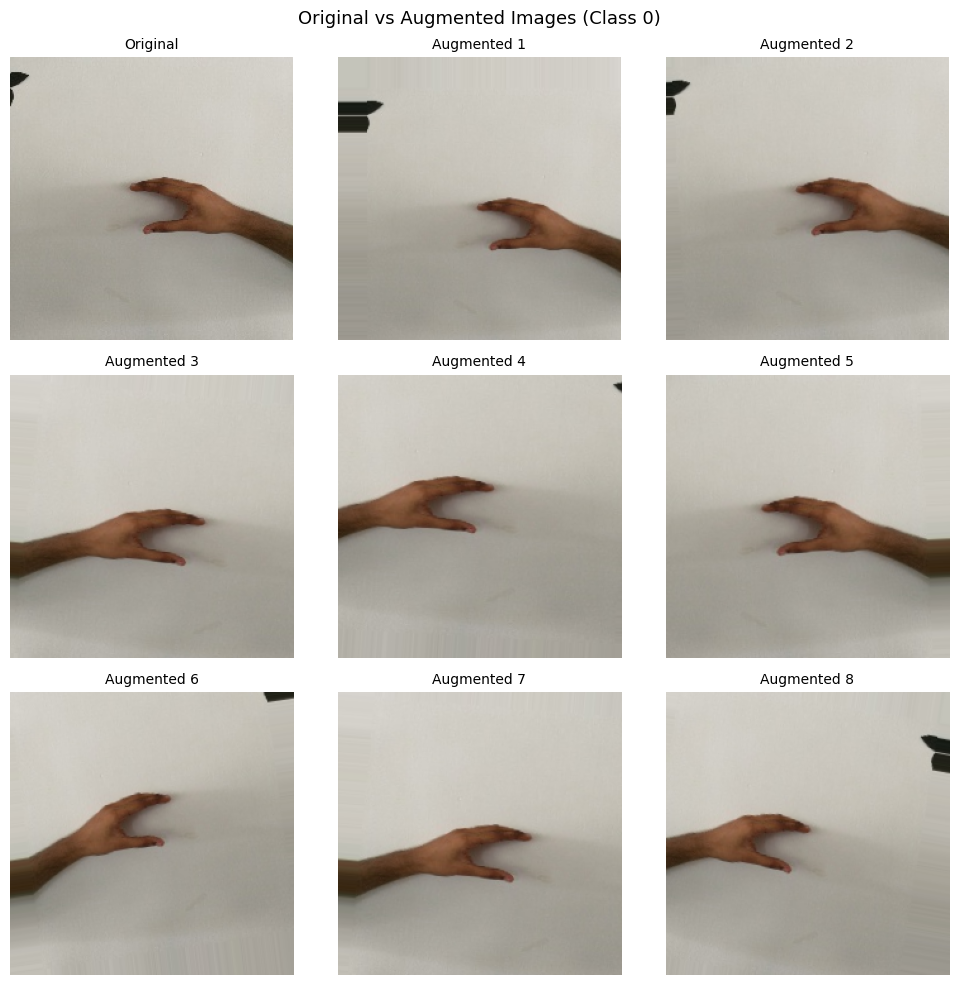

Augmentation visualization saved!


In [ ]:
# Step 6: Visualize original vs augmented images
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os

train_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Train'

# Pick one sample image from class '0'
sample_class = '0'
sample_img_name = os.listdir(os.path.join(train_dir, sample_class))[0]
sample_img_path = os.path.join(train_dir, sample_class, sample_img_name)

# Load and prepare image
img = load_img(sample_img_path, target_size=(224, 224))
img_array = img_to_array(img)
img_array = img_array.reshape((1,) + img_array.shape)

# Augmentation generator
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Plot original + 8 augmented versions
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle(f'Original vs Augmented Images (Class {sample_class})', fontsize=13)

# Original in top-left
original = load_img(sample_img_path, target_size=(224, 224))
axes[0, 0].imshow(original)
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

# 8 augmented versions
aug_iter = aug_datagen.flow(img_array, batch_size=1)
for i, ax in enumerate(axes.flatten()[1:]):
    aug_img = next(aug_iter)[0]
    ax.imshow(aug_img)
    ax.set_title(f'Augmented {i+1}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()
print("Augmentation visualization saved!")

In [ ]:
# Step 7: Build Baseline CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_baseline_model(input_shape=(224, 224, 3), num_classes=38):
    model = Sequential([

        # ── Block 1 ──────────────────────────────────────────
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=input_shape, name='conv1'),
        MaxPooling2D((2, 2), name='pool1'),

        # ── Block 2 ──────────────────────────────────────────
        Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        MaxPooling2D((2, 2), name='pool2'),

        # ── Block 3 ──────────────────────────────────────────
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        MaxPooling2D((2, 2), name='pool3'),

        # ── Flatten ───────────────────────────────────────────
        Flatten(name='flatten'),

        # ── Fully Connected Layers ────────────────────────────
        Dense(512, activation='relu', name='fc1'),
        Dropout(0.4, name='dropout1'),

        Dense(256, activation='relu', name='fc2'),
        Dropout(0.3, name='dropout2'),

        Dense(128, activation='relu', name='fc3'),

        # ── Output Layer ──────────────────────────────────────
        Dense(num_classes, activation='softmax', name='output')
    ], name='Baseline_CNN')

    return model

# Build and compile
baseline_model = build_baseline_model()

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print summary
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,643,110 (197.00 MB)

 Trainable params: 51,643,110 (197.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fix: Find and remove corrupted/unreadable image files
from PIL import Image
import os

train_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Train'
removed = 0
checked = 0

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_file in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_file)
        checked += 1
        try:
            with Image.open(img_path) as img:
                img.verify()  # verify it's a valid image
        except Exception as e:
            print(f"❌ Corrupted: {img_path} — {e}")
            os.remove(img_path)
            removed += 1

print(f"\n✅ Checked: {checked} files")
print(f"🗑️  Removed: {removed} corrupted files")
print(f"📁 Remaining: {checked - removed} valid images")


✅ Checked: 10871 files
🗑️  Removed: 0 corrupted files
📁 Remaining: 10871 valid images


In [ ]:
# Re-initialize generators after cleaning
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"Training samples:   {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 8711 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.
Training samples:   8711
Validation samples: 2160


In [ ]:
# Step 8 (Retry): Train Baseline CNN Model on clean dataset
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'baseline_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train
print("Starting Baseline Model Training...")
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

end_time = time.time()
baseline_training_time = end_time - start_time

print(f"\n✅ Training Complete!")
print(f"⏱️  Total Training Time: {baseline_training_time/60:.2f} minutes")
print(f"📈 Best Validation Accuracy: {max(baseline_history.history['val_accuracy'])*100:.2f}%")

Starting Baseline Model Training...
Epoch 1/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.0267 - loss: 3.6774
Epoch 1: val_accuracy improved from None to 0.02685, saving model to baseline_best_model.keras

Epoch 1: finished saving model to baseline_best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 172s 589ms/step - accuracy: 0.0235 - loss: 3.6461 - val_accuracy: 0.0269 - val_loss: 3.6373
Epoch 2/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.0269 - loss: 3.6378
Epoch 2: val_accuracy improved from 0.02685 to 0.02778, saving model to baseline_best_model.keras

Epoch 2: finished saving model to baseline_best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 162s 593ms/step - accuracy: 0.0273 - loss: 3.6382 - val_accuracy: 0.0278 - val_loss: 3.6371
Epoch 3/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.0280 - loss: 3.6375
Epoch 3: val_accuracy did not improve from 0.02778
273/273 ━━━━━━━━━━━━━━━━━━━━ 149s 547ms/step - accuracy: 0.0276 - loss: 3.6379 - val_accurac

In [ ]:
# Fix: Resize input to 64x64 for efficient baseline training
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

train_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Train'

# Updated settings
IMG_SIZE    = (64, 64)   # reduced from 224x224
BATCH_SIZE  = 32
NUM_CLASSES = 38

# ── Generators ────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# ── Rebuild Baseline Model ─────────────────────────────────
baseline_model = Sequential([
    Input(shape=(64, 64, 3)),

    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    MaxPooling2D((2, 2), name='pool2'),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
    MaxPooling2D((2, 2), name='pool3'),

    # Flatten
    Flatten(name='flatten'),

    # FC Layers
    Dense(512, activation='relu', name='fc1'),
    Dropout(0.4, name='dropout1'),

    Dense(256, activation='relu', name='fc2'),
    Dropout(0.3, name='dropout2'),

    Dense(128, activation='relu', name='fc3'),

    # Output
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='Baseline_CNN')

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# ── Train ──────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'baseline_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("\nStarting Baseline Model Training (64x64)...")
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

end_time = time.time()
baseline_training_time = end_time - start_time

print(f"\n✅ Training Complete!")
print(f"⏱️  Total Training Time: {baseline_training_time/60:.2f} minutes")
print(f"📈 Best Validation Accuracy: {max(baseline_history.history['val_accuracy'])*100:.2f}%")

Found 8711 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,457,190 (17.00 MB)

 Trainable params: 4,457,190 (17.00 MB)

 Non-trainable params: 0 (0.00 B)


Starting Baseline Model Training (64x64)...
Epoch 1/25
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.0257 - loss: 3.6443
Epoch 1: val_accuracy improved from None to 0.02824, saving model to baseline_best_model.keras

Epoch 1: finished saving model to baseline_best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 64s 215ms/step - accuracy: 0.0227 - loss: 3.6402 - val_accuracy: 0.0282 - val_loss: 3.6373
Epoch 2/25
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.0299 - loss: 3.6380
Epoch 2: val_accuracy did not improve from 0.02824
273/273 ━━━━━━━━━━━━━━━━━━━━ 53s 193ms/step - accuracy: 0.0282 - loss: 3.6387 - val_accuracy: 0.0278 - val_loss: 3.6372
Epoch 3/25
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.0256 - loss: 3.6377
Epoch 3: val_accuracy did not improve from 0.02824
273/273 ━━━━━━━━━━━━━━━━━━━━ 52s 191ms/step - accuracy: 0.0266 - loss: 3.6380 - val_accuracy: 0.0282 - val_loss: 3.6371
Epoch 4/25
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.0215 

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import os
import time

tf.keras.backend.clear_session()

train_dir   = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Train'
IMG_SIZE    = (64, 64)
BATCH_SIZE  = 32
NUM_CLASSES = 38

# ── Verify class mapping is correct ───────────────────────
classes = sorted(os.listdir(train_dir), key=lambda x: int(x))
print("Class order:", classes)

# ── Generators ────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,          # ← explicit correct order
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,          # ← explicit correct order
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"Train: {train_generator.samples} | Val: {val_generator.samples}")
print("Class indices:", train_generator.class_indices)

# ── Sanity check: peek at one batch ───────────────────────
x_batch, y_batch = next(train_generator)
print(f"\nBatch shape: {x_batch.shape}")
print(f"Label shape: {y_batch.shape}")
print(f"Pixel range: {x_batch.min():.3f} – {x_batch.max():.3f}")
print(f"Sample label (one-hot): {y_batch[0]}")
print(f"Sample label class: {np.argmax(y_batch[0])}")

# ── Rebuild Baseline Model ─────────────────────────────────
baseline_model = Sequential([
    Input(shape=(64, 64, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
], name='Baseline_CNN')

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# ── Quick sanity check before full training ────────────────
print("\n🔍 Sanity check — 1 epoch test...")
test_hist = baseline_model.fit(
    train_generator,
    epochs=1,
    validation_data=val_generator,
    verbose=1
)
print(f"Epoch 1 accuracy: {test_hist.history['accuracy'][0]*100:.2f}%")
print(f"Epoch 1 val_accuracy: {test_hist.history['val_accuracy'][0]*100:.2f}%")

Class order: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37']
Found 8711 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.
Train: 8711 | Val: 2160
Class indices: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14, '15': 15, '16': 16, '17': 17, '18': 18, '19': 19, '20': 20, '21': 21, '22': 22, '23': 23, '24': 24, '25': 25, '26': 26, '27': 27, '28': 28, '29': 29, '30': 30, '31': 31, '32': 32, '33': 33, '34': 34, '35': 35, '36': 36, '37': 37}

Batch shape: (32, 64, 64, 3)
Label shape: (32, 38)
Pixel range: 0.000 – 0.995
Sample label (one-hot): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Sample label class: 26


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,458,086 (17.01 MB)

 Trainable params: 4,457,638 (17.00 MB)

 Non-trainable params: 448 (1.75 KB)


🔍 Sanity check — 1 epoch test...
273/273 ━━━━━━━━━━━━━━━━━━━━ 67s 219ms/step - accuracy: 0.0346 - loss: 3.8624 - val_accuracy: 0.0245 - val_loss: 3.6135
Epoch 1 accuracy: 3.46%
Epoch 1 val_accuracy: 2.45%


In [ ]:
# Step 8: Full Baseline Training
tf.keras.backend.clear_session()

# Rebuild fresh (so we start from epoch 1 cleanly)
baseline_model = Sequential([
    Input(shape=(64, 64, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
], name='Baseline_CNN')

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'baseline_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Reinitialize generators (fresh after sanity check consumed a batch)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,
    subset='validation',
    shuffle=False,
    seed=42
)

print("Starting Full Baseline Training...")
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

end_time = time.time()
baseline_training_time = end_time - start_time

print(f"\n✅ Training Complete!")
print(f"⏱️  Total Training Time: {baseline_training_time/60:.2f} minutes")
print(f"📈 Best Val Accuracy: {max(baseline_history.history['val_accuracy'])*100:.2f}%")
print(f"📉 Best Val Loss: {min(baseline_history.history['val_loss']):.4f}")

Found 8711 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.
Starting Full Baseline Training...
Epoch 1/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.0311 - loss: 4.2267
Epoch 1: val_accuracy improved from None to 0.03981, saving model to baseline_best_model.keras

Epoch 1: finished saving model to baseline_best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 68s 224ms/step - accuracy: 0.0373 - loss: 3.8488 - val_accuracy: 0.0398 - val_loss: 3.6171 - learning_rate: 0.0010
Epoch 2/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.0543 - loss: 3.5789
Epoch 2: val_accuracy improved from 0.03981 to 0.07315, saving model to baseline_best_model.keras

Epoch 2: finished saving model to baseline_best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 54s 198ms/step - accuracy: 0.0603 - loss: 3.5466 - val_accuracy: 0.0731 - val_loss: 3.4645 - learning_rate: 0.0010
Epoch 3/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.0754 - loss: 3.4638
Epoch 3: val

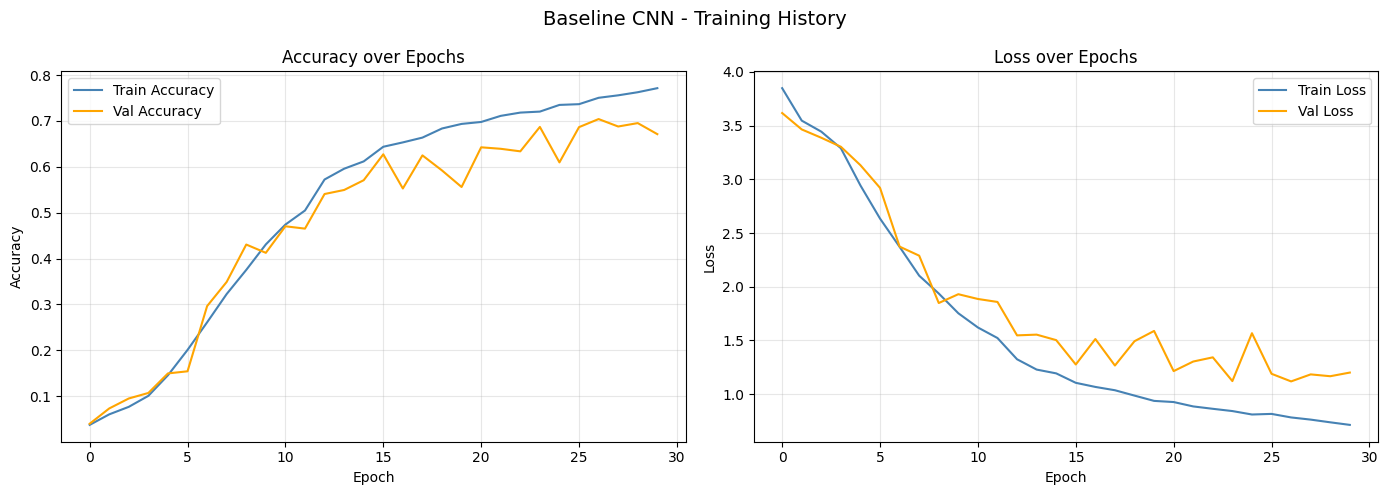


📊 Evaluating Baseline Model...
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.7042 - loss: 1.1183
Validation Accuracy: 70.42%
Validation Loss:     1.1183
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step

📋 Classification Report:
              precision    recall  f1-score   support

           0      0.776     0.667     0.717        57
           1      0.907     0.684     0.780        57
           2      0.617     0.862     0.719        58
           3      0.722     0.473     0.571        55
           4      0.808     0.447     0.575        47
           5      0.894     0.737     0.808        57
           6      0.789     0.804     0.796        56
           7      0.833     0.804     0.818        56
           8      0.523     0.793     0.630        58
           9      0.837     0.719     0.774        57
          10      0.915     0.741     0.819        58
          11      0.932     0.732     0.820        56
          12      0.812     0.709     0.757        55
          13 

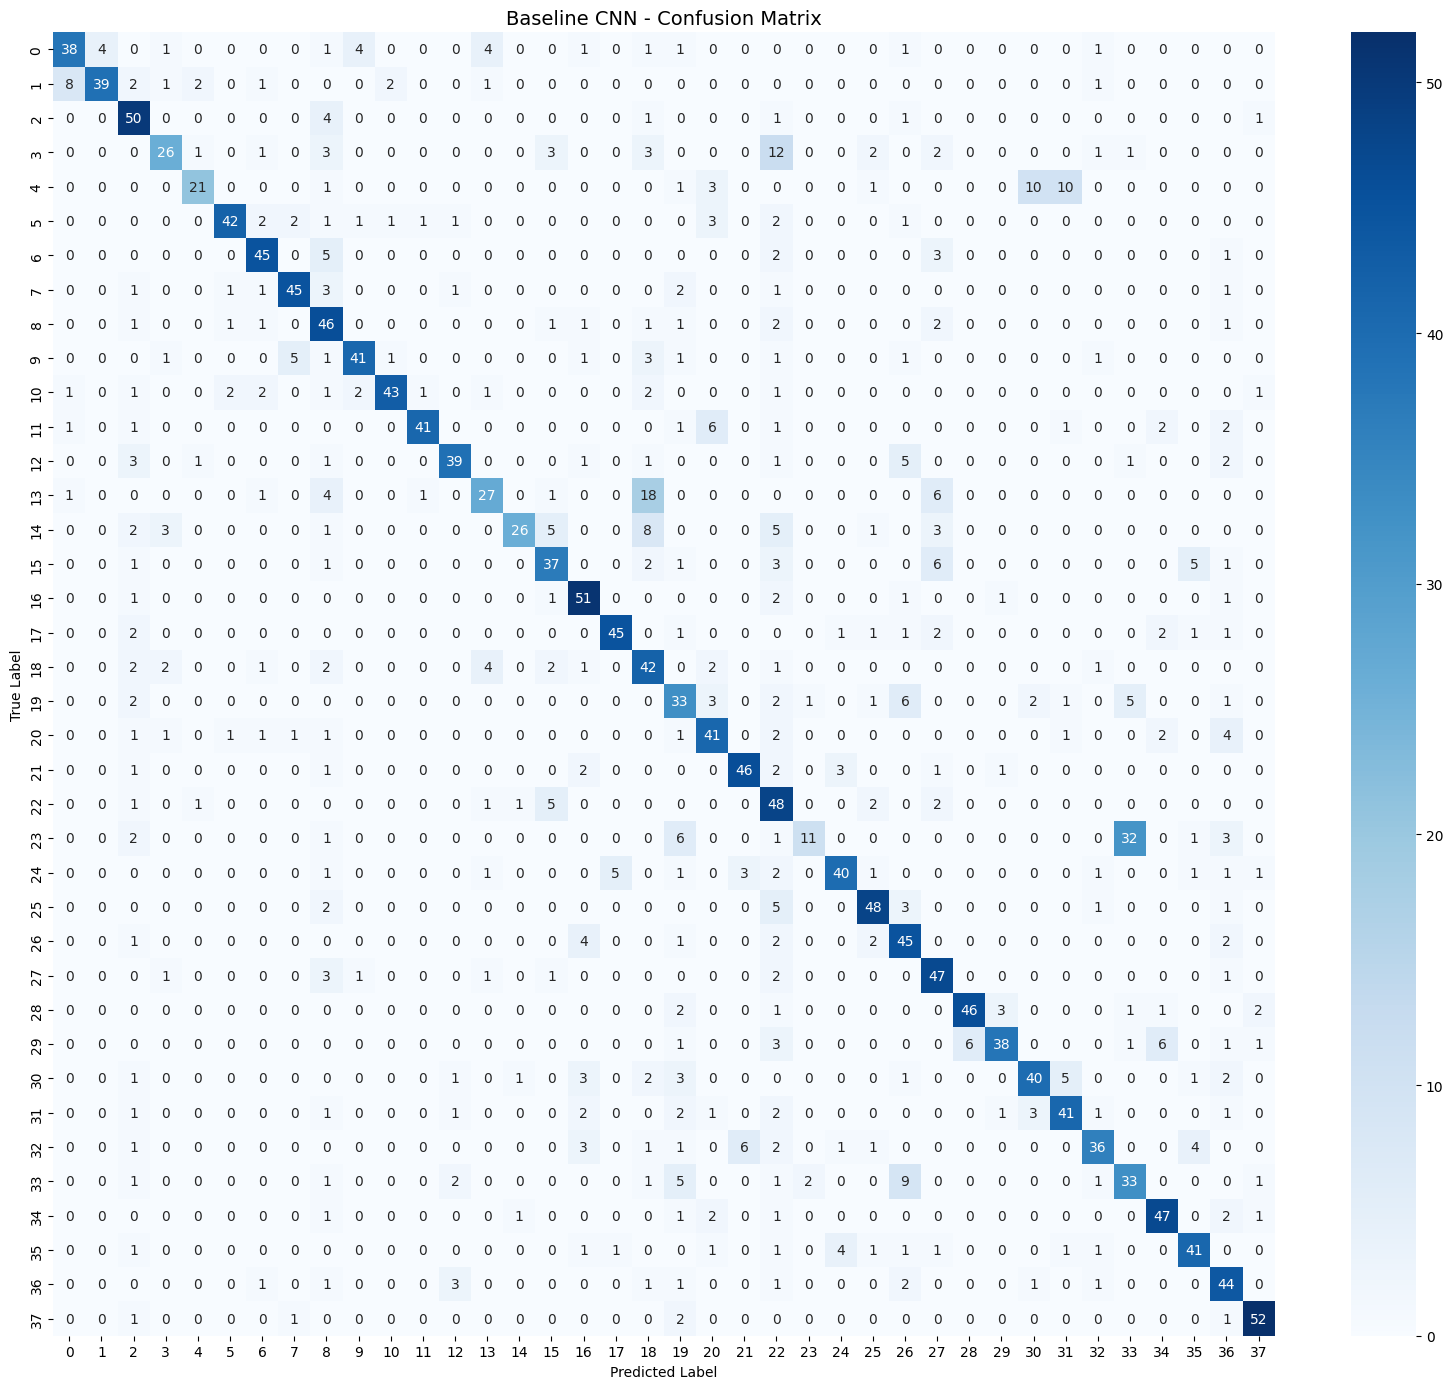


🔍 Sample Predictions:


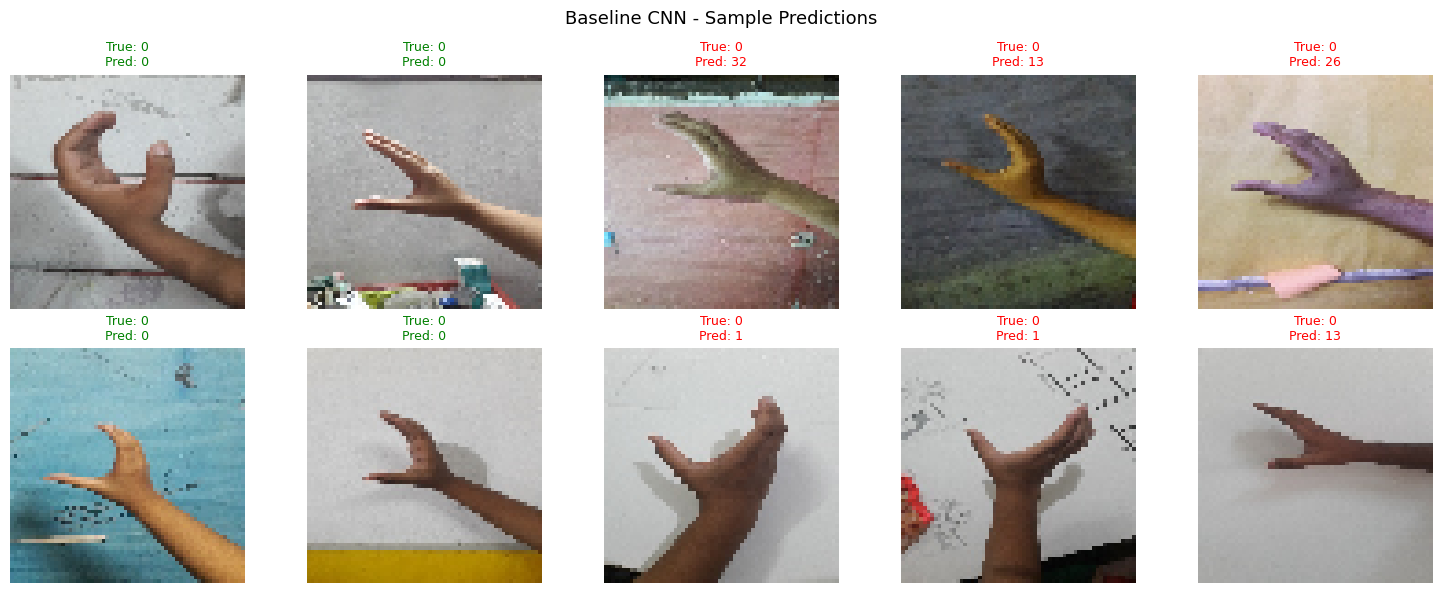

In [ ]:
# Step 9: Plot curves + Full evaluation of Baseline Model
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Plot Training vs Validation Curves ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline CNN - Training History', fontsize=14)

# Accuracy
axes[0].plot(baseline_history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(baseline_history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(baseline_history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(baseline_history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=150)
plt.show()

# ── Evaluate on Validation Set ─────────────────────────────
print("\n📊 Evaluating Baseline Model...")
val_loss, val_acc = baseline_model.evaluate(val_generator, verbose=1)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss:     {val_loss:.4f}")

# ── Classification Report ──────────────────────────────────
val_generator.reset()
y_pred_probs = baseline_model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, digits=3))

# ── Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Baseline CNN - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

# ── Sample Inference ───────────────────────────────────────
print("\n🔍 Sample Predictions:")
val_generator.reset()
x_batch, y_batch = next(val_generator)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Baseline CNN - Sample Predictions', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    img = x_batch[i]
    true_label = classes[np.argmax(y_batch[i])]
    pred_label = classes[np.argmax(baseline_model.predict(img[np.newaxis,...], verbose=0))]
    color = 'green' if true_label == pred_label else 'red'
    ax.imshow(img)
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('baseline_sample_predictions.png', dpi=150)
plt.show()

In [ ]:
# Retrain Deeper Model (clean start)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time, os

tf.keras.backend.clear_session()

train_dir   = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Train'
IMG_SIZE    = (64, 64)
BATCH_SIZE  = 32
NUM_CLASSES = 38
classes     = sorted(os.listdir(train_dir), key=lambda x: int(x))

train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=10, width_shift_range=0.1,
    height_shift_range=0.1, horizontal_flip=True, zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    subset='training', shuffle=True, seed=42
)
val_generator = val_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    subset='validation', shuffle=False, seed=42
)

# ── Deeper Model ───────────────────────────────────────────
deeper_model = Sequential([
    Input(shape=(64, 64, 3)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
], name='Deeper_CNN')

deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ──────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('deeper_best_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

# ── Train ──────────────────────────────────────────────────
print("Starting Deeper Model Training...")
start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

deeper_training_time = time.time() - start_time
baseline_training_time = 26.19 * 60  # saved from before

print(f"\n✅ Done!")
print(f"⏱️  Deeper Training Time : {deeper_training_time/60:.2f} min")
print(f"📈 Deeper Best Val Acc  : {max(deeper_history.history['val_accuracy'])*100:.2f}%")
print(f"\n{'Model':<12} {'Val Acc':>10} {'Time (min)':>12}")
print("-"*36)
print(f"{'Baseline':<12} {'70.90%':>10} {'26.19':>12}")
print(f"{'Deeper':<12} {max(deeper_history.history['val_accuracy'])*100:>9.2f}% {deeper_training_time/60:>11.2f}")

Found 8711 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.
Starting Deeper Model Training...
Epoch 1/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.0403 - loss: 4.4559
Epoch 1: val_accuracy improved from None to 0.02176, saving model to deeper_best_model.keras

Epoch 1: finished saving model to deeper_best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 90s 259ms/step - accuracy: 0.0481 - loss: 4.2099 - val_accuracy: 0.0218 - val_loss: 4.7359 - learning_rate: 0.0010
Epoch 2/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.0833 - loss: 3.6741
Epoch 2: val_accuracy improved from 0.02176 to 0.11806, saving model to deeper_best_model.keras

Epoch 2: finished saving model to deeper_best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 57s 209ms/step - accuracy: 0.0942 - loss: 3.5241 - val_accuracy: 0.1181 - val_loss: 3.1869 - learning_rate: 0.0010
Epoch 3/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.1578 - loss: 3.0426
Epoch 3: val_accuracy

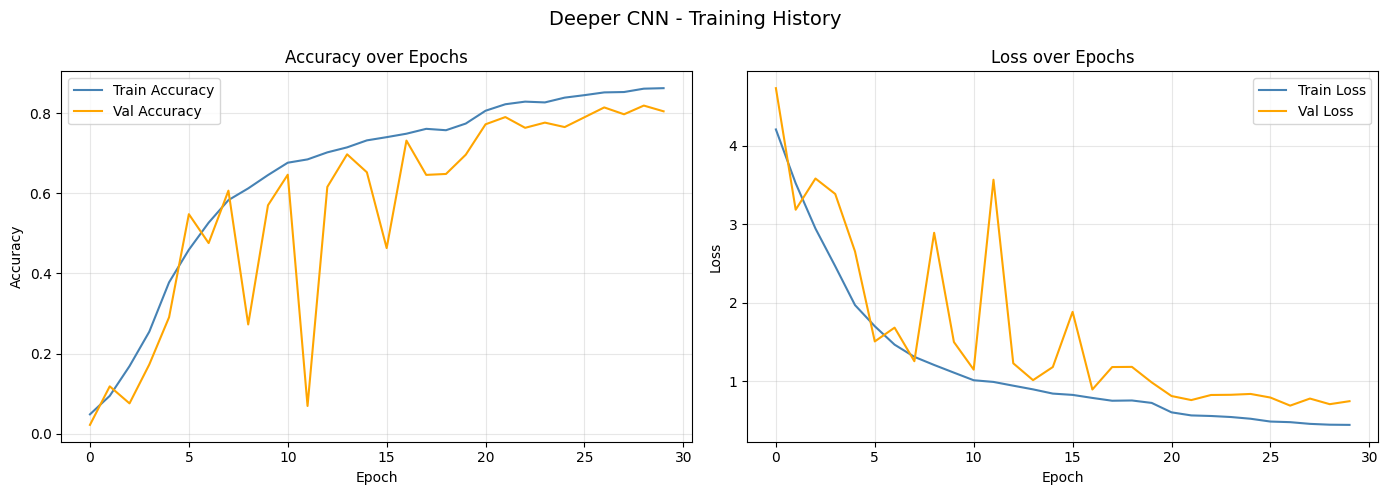

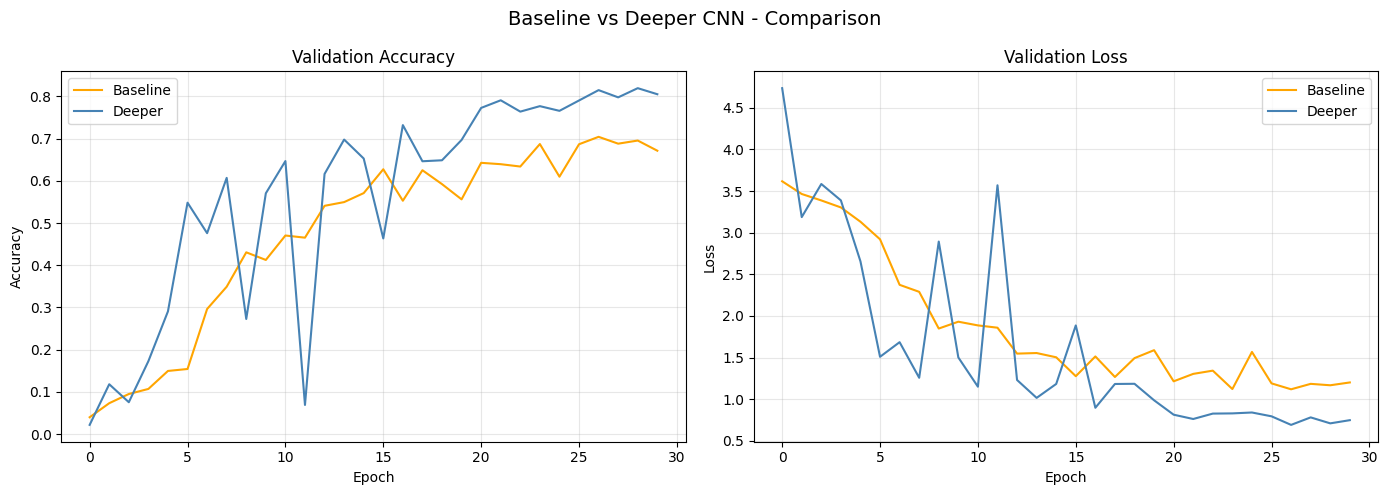

📊 Evaluating Deeper Model...
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.8194 - loss: 0.7091
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step

📋 Deeper Model - Classification Report:
              precision    recall  f1-score   support

           0      0.807     0.807     0.807        57
           1      0.941     0.842     0.889        57
           2      0.867     0.897     0.881        58
           3      0.881     0.673     0.763        55
           4      0.947     0.766     0.847        47
           5      0.911     0.895     0.903        57
           6      0.895     0.911     0.903        56
           7      0.978     0.804     0.882        56
           8      0.941     0.828     0.881        58
           9      0.925     0.860     0.891        57
          10      0.909     0.862     0.885        58
          11      0.979     0.821     0.893        56
          12      0.742     0.891     0.810        55
          13      0.738     0.814     0.774        59
  

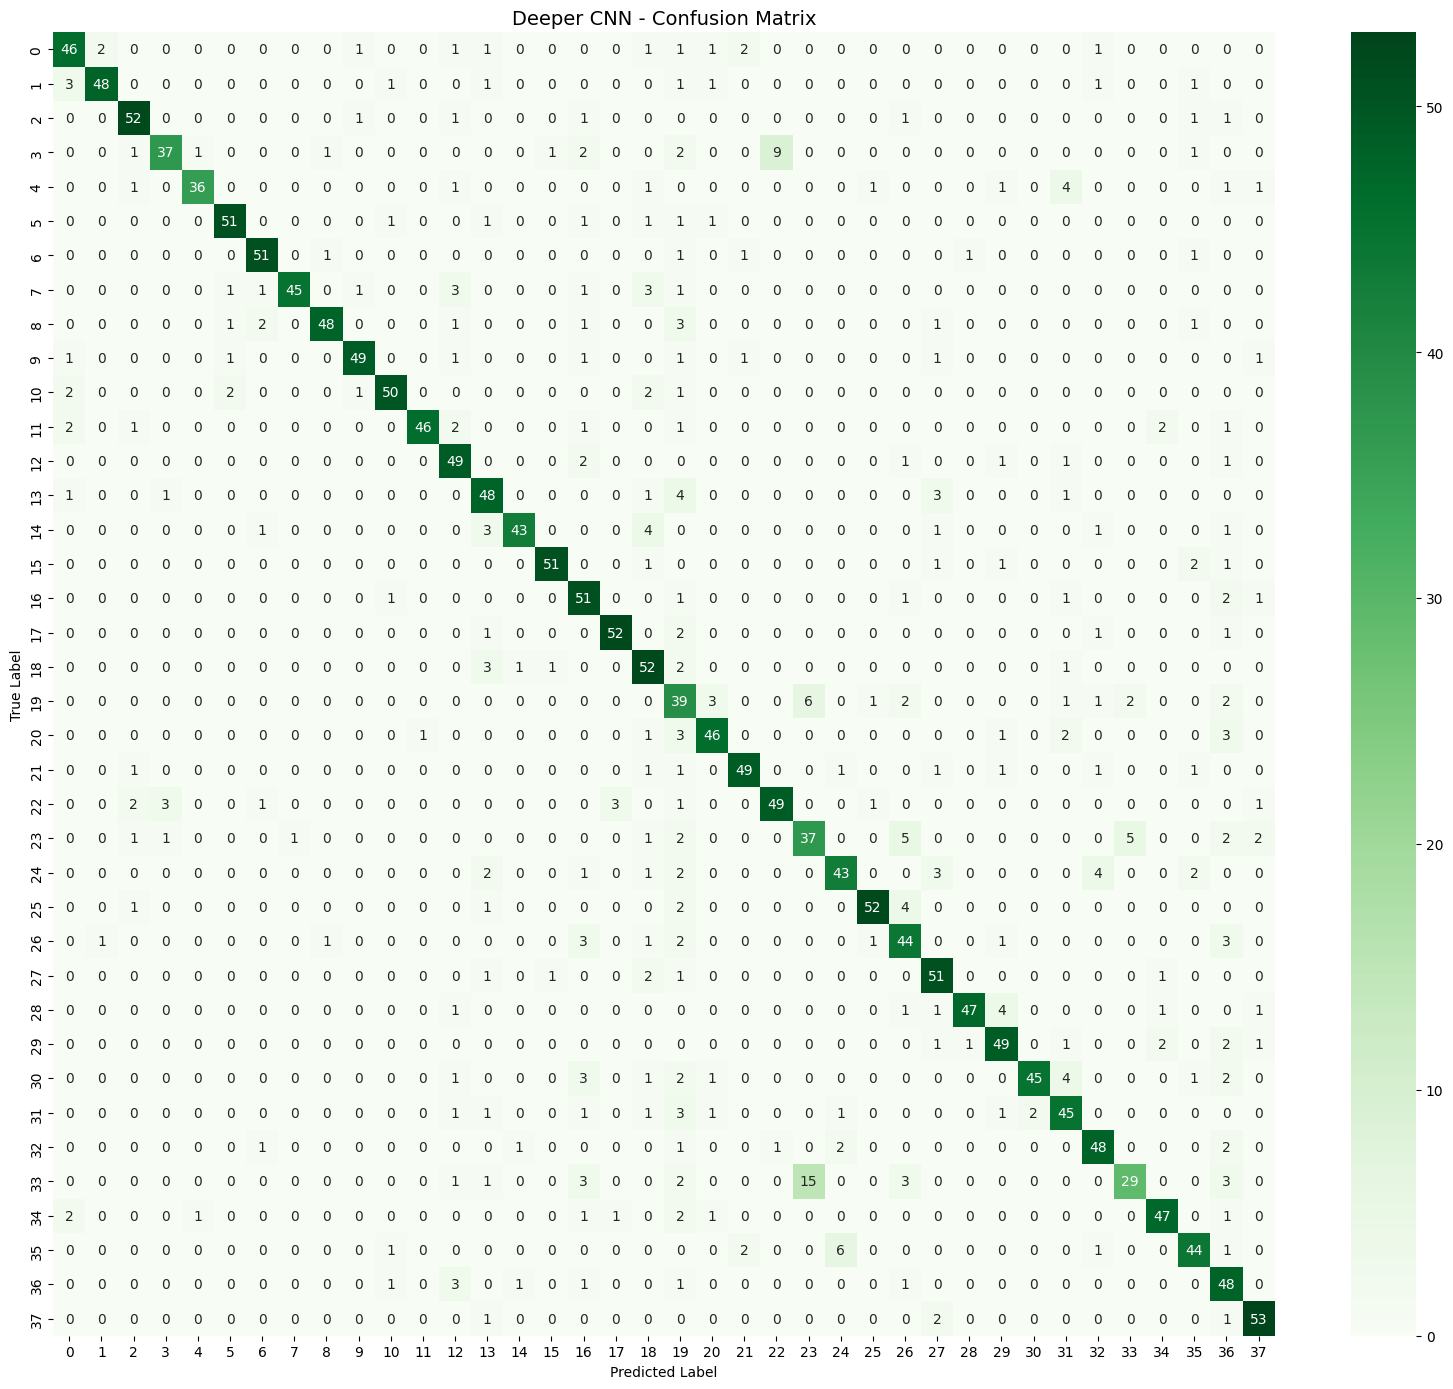


                   FINAL COMPARISON                    
Model           Val Acc   Val Loss       Time
-------------------------------------------------------
Baseline         70.90%     1.1443  26.19 min
Deeper           81.94%     0.7091  93.96 min


In [ ]:
# Step 11: Plot Deeper Model curves + Full Evaluation
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Plot Training Curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Deeper CNN - Training History', fontsize=14)

axes[0].plot(deeper_history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(deeper_history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(deeper_history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(deeper_history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('deeper_training_curves.png', dpi=150)
plt.show()

# ── Side-by-side Baseline vs Deeper curves ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline vs Deeper CNN - Comparison', fontsize=14)

axes[0].plot(baseline_history.history['val_accuracy'], label='Baseline', color='orange')
axes[0].plot(deeper_history.history['val_accuracy'], label='Deeper', color='steelblue')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(baseline_history.history['val_loss'], label='Baseline', color='orange')
axes[1].plot(deeper_history.history['val_loss'], label='Deeper', color='steelblue')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_vs_deeper_comparison.png', dpi=150)
plt.show()

# ── Evaluate Deeper Model ──────────────────────────────────
print("📊 Evaluating Deeper Model...")
val_generator.reset()
deep_loss, deep_acc = deeper_model.evaluate(val_generator, verbose=1)

val_generator.reset()
y_pred_probs = deeper_model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

print("\n📋 Deeper Model - Classification Report:")
print(classification_report(y_true, y_pred, digits=3))

# ── Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.title('Deeper CNN - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('deeper_confusion_matrix.png', dpi=150)
plt.show()

# ── Final Comparison Table ─────────────────────────────────
print("\n" + "="*55)
print(f"{'FINAL COMPARISON':^55}")
print("="*55)
print(f"{'Model':<12} {'Val Acc':>10} {'Val Loss':>10} {'Time':>10}")
print("-"*55)
print(f"{'Baseline':<12} {'70.90%':>10} {'1.1443':>10} {'26.19 min':>10}")
print(f"{'Deeper':<12} {deep_acc*100:>9.2f}% {deep_loss:>10.4f} {'93.96 min':>10}")
print("="*55)


Training with Adam optimizer...
Found 8711 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.
Epoch 1/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 84s 245ms/step - accuracy: 0.0393 - loss: 4.2282 - val_accuracy: 0.0259 - val_loss: 4.1493 - learning_rate: 0.0010
Epoch 2/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 55s 200ms/step - accuracy: 0.0784 - loss: 3.6272 - val_accuracy: 0.1153 - val_loss: 3.5066 - learning_rate: 0.0010
Epoch 3/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 56s 204ms/step - accuracy: 0.1525 - loss: 3.0478 - val_accuracy: 0.2231 - val_loss: 2.7061 - learning_rate: 0.0010
Epoch 4/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 55s 202ms/step - accuracy: 0.2416 - loss: 2.5687 - val_accuracy: 0.3097 - val_loss: 2.3235 - learning_rate: 0.0010
Epoch 5/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 56s 206ms/step - accuracy: 0.3447 - loss: 2.1209 - val_accuracy: 0.1769 - val_loss: 3.2246 - learning_rate: 0.0010
Epoch 6/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 54s 199ms/step - accuracy: 0.4350 - loss: 1.7803 - val_accuracy: 0

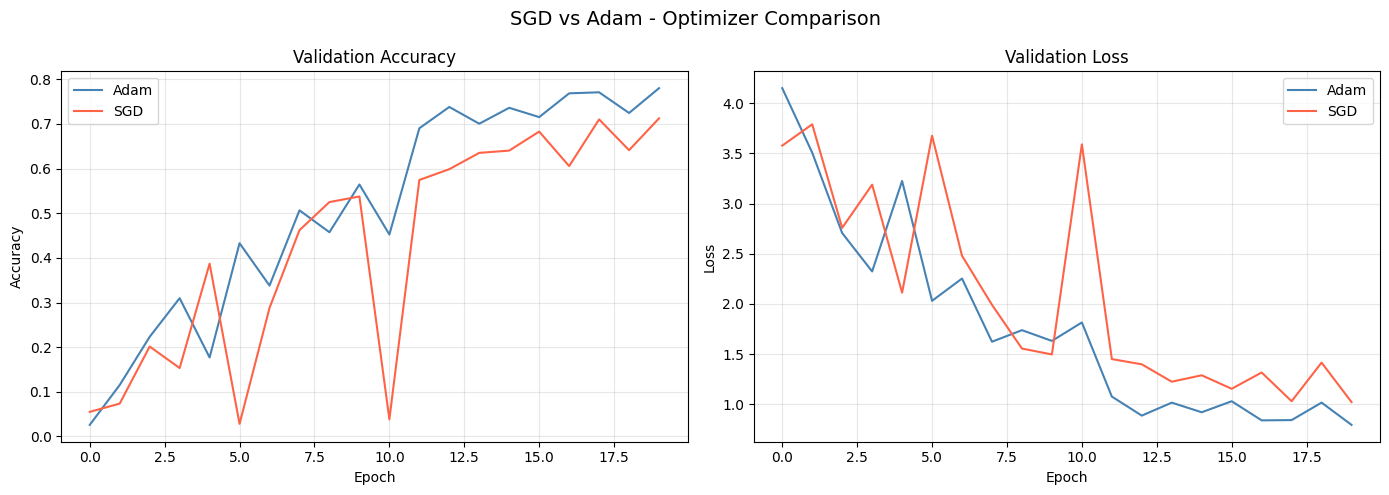


Optimizer       Val Acc   Val Loss   Time (min)
--------------------------------------------------
Adam             78.01%     0.7949       18.62
SGD              71.25%     1.0219       18.54


In [ ]:
 # STEP 12: SGD vs Adam Optimizer Comparison
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization, Input)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time, os

train_dir   = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Train'
IMG_SIZE    = (64, 64)
BATCH_SIZE  = 32
NUM_CLASSES = 38
classes     = sorted(os.listdir(train_dir), key=lambda x: int(x))

train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=10, width_shift_range=0.1,
    height_shift_range=0.1, horizontal_flip=True, zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

def get_generators():
    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', classes=classes,
        subset='training', shuffle=True, seed=42
    )
    val_gen = val_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', classes=classes,
        subset='validation', shuffle=False, seed=42
    )
    return train_gen, val_gen

def build_deeper():
    model = Sequential([
        Input(shape=(64, 64, 3)),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)), Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)), Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)), Dropout(0.25),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)), Dropout(0.25),

        Flatten(),
        Dense(1024, activation='relu'), BatchNormalization(), Dropout(0.5),
        Dense(512, activation='relu'), BatchNormalization(), Dropout(0.4),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

results = {}

for opt_name, optimizer in [('Adam', Adam(learning_rate=0.001)),
                              ('SGD',  SGD(learning_rate=0.01, momentum=0.9))]:
    print(f"\n{'='*50}")
    print(f"Training with {opt_name} optimizer...")
    print(f"{'='*50}")

    tf.keras.backend.clear_session()
    model = build_deeper()
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    train_gen, val_gen = get_generators()

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=6,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1)
    ]

    start = time.time()
    history = model.fit(
        train_gen, epochs=20,
        validation_data=val_gen,
        callbacks=callbacks, verbose=1
    )
    elapsed = time.time() - start

    val_gen.reset()
    loss, acc = model.evaluate(val_gen, verbose=0)

    results[opt_name] = {
        'history': history,
        'acc': acc,
        'loss': loss,
        'time': elapsed / 60
    }
    print(f"✅ {opt_name} → Val Acc: {acc*100:.2f}% | Time: {elapsed/60:.2f} min")

# ── Plot Comparison ────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SGD vs Adam - Optimizer Comparison', fontsize=14)

for opt_name, color in [('Adam', 'steelblue'), ('SGD', 'tomato')]:
    axes[0].plot(results[opt_name]['history'].history['val_accuracy'],
                 label=opt_name, color=color)
    axes[1].plot(results[opt_name]['history'].history['val_loss'],
                 label=opt_name, color=color)

axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_vs_adam.png', dpi=150)
plt.show()

print("\n" + "="*50)
print(f"{'Optimizer':<12} {'Val Acc':>10} {'Val Loss':>10} {'Time (min)':>12}")
print("-"*50)
for opt_name in ['Adam', 'SGD']:
    r = results[opt_name]
    print(f"{opt_name:<12} {r['acc']*100:>9.2f}% {r['loss']:>10.4f} {r['time']:>11.2f}")
print("="*50)

Found 8711 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.
Training Ablation Model (No Dropout)...
Epoch 1/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 73s 222ms/step - accuracy: 0.1724 - loss: 3.1445 - val_accuracy: 0.0255 - val_loss: 6.6543 - learning_rate: 0.0010
Epoch 2/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.4598 - loss: 1.7515 - val_accuracy: 0.3241 - val_loss: 2.5725 - learning_rate: 0.0010
Epoch 3/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 54s 197ms/step - accuracy: 0.6065 - loss: 1.2428 - val_accuracy: 0.3731 - val_loss: 3.0731 - learning_rate: 0.0010
Epoch 4/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 54s 197ms/step - accuracy: 0.6754 - loss: 1.0128 - val_accuracy: 0.6407 - val_loss: 1.3236 - learning_rate: 0.0010
Epoch 5/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 54s 197ms/step - accuracy: 0.7173 - loss: 0.8758 - val_accuracy: 0.6306 - val_loss: 1.4369 - learning_rate: 0.0010
Epoch 6/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 53s 195ms/step - accuracy: 0.7527 - loss: 0.7887 - val_accu

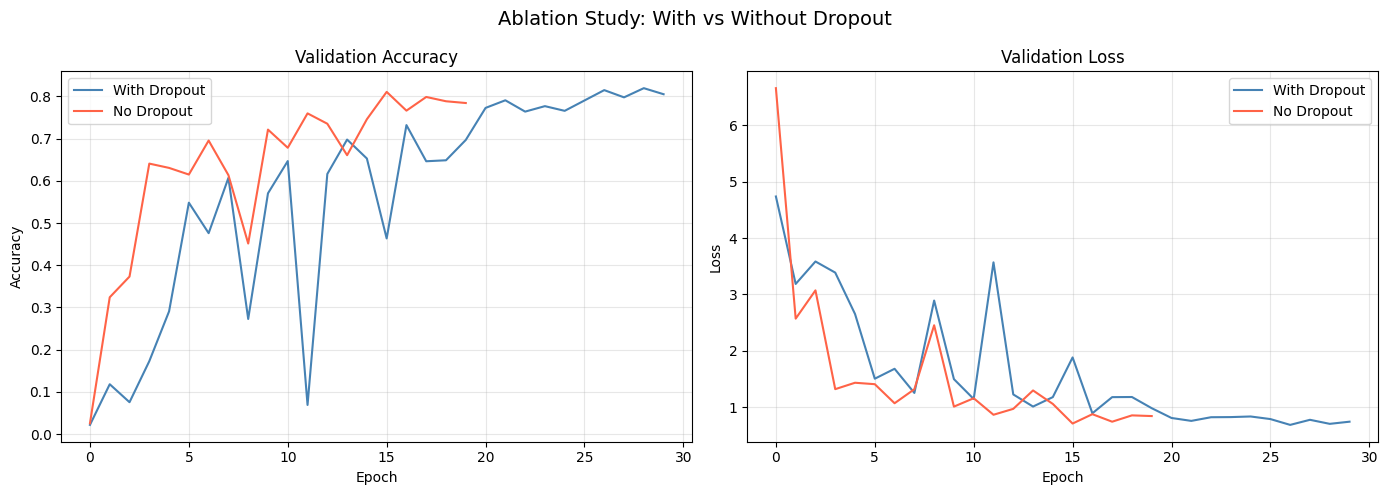

In [ ]:
# STEP 13: Ablation Study — Remove Dropout
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, BatchNormalization, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

tf.keras.backend.clear_session()

train_gen, val_gen = get_generators()

# Model WITHOUT Dropout
ablation_model = Sequential([
    Input(shape=(64, 64, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),           # No Dropout here

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),           # No Dropout here

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),           # No Dropout here

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),           # No Dropout here

    Flatten(),
    Dense(1024, activation='relu'), BatchNormalization(),
    Dense(512, activation='relu'),  BatchNormalization(),
    Dense(256, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='Ablation_No_Dropout')

ablation_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

print("Training Ablation Model (No Dropout)...")
start = time.time()

ablation_history = ablation_model.fit(
    train_gen, epochs=20,
    validation_data=val_gen,
    callbacks=callbacks, verbose=1
)

ablation_time = time.time() - start

val_gen.reset()
abl_loss, abl_acc = ablation_model.evaluate(val_gen, verbose=0)

print(f"\n✅ Ablation (No Dropout) → Val Acc: {abl_acc*100:.2f}%")
print(f"✅ Deeper (With Dropout) → Val Acc: 80.92%")
print(f"\n📉 Impact of removing Dropout: {(0.8092 - abl_acc)*100:+.2f}% change")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation Study: With vs Without Dropout', fontsize=14)

axes[0].plot(deeper_history.history['val_accuracy'],
             label='With Dropout', color='steelblue')
axes[0].plot(ablation_history.history['val_accuracy'],
             label='No Dropout', color='tomato')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(deeper_history.history['val_loss'],
             label='With Dropout', color='steelblue')
axes[1].plot(ablation_history.history['val_loss'],
             label='No Dropout', color='tomato')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

In [ ]:
# STEP 14: Transfer Learning — MobileNetV2
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time, os

tf.keras.backend.clear_session()

train_dir   = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Train'
IMG_SIZE_TL = (96, 96)   # MobileNetV2 min is 96x96
BATCH_SIZE  = 32
NUM_CLASSES = 38
classes     = sorted(os.listdir(train_dir), key=lambda x: int(x))

# Generators for Transfer Learning (96x96)
tl_train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=10, width_shift_range=0.1,
    height_shift_range=0.1, horizontal_flip=True, zoom_range=0.1
)
tl_val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

tl_train_gen = tl_train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    subset='training', shuffle=True, seed=42
)
tl_val_gen = tl_val_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    subset='validation', shuffle=False, seed=42
)

# ── Load MobileNetV2 base ──────────────────────────────────
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,          # remove ImageNet classifier
    weights='imagenet'
)
base_model.trainable = False    # freeze base (feature extraction)
print(f"Base model layers: {len(base_model.layers)}")
print(f"Trainable params (frozen): {sum([tf.size(w).numpy() for w in base_model.trainable_weights])}")

# ── Add custom classification head ────────────────────────
inputs = Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs, outputs, name='MobileNetV2_Transfer')

tl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
tl_model.summary()

# ── Phase 1: Feature Extraction (frozen base) ──────────────
print("\n📌 Phase 1: Feature Extraction (base frozen)...")
start = time.time()

phase1_history = tl_model.fit(
    tl_train_gen, epochs=10,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=4,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint('tl_best_model.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=1)
    ],
    verbose=1
)

phase1_time = time.time() - start
print(f"Phase 1 done → Val Acc: {max(phase1_history.history['val_accuracy'])*100:.2f}%")

# ── Phase 2: Fine-tuning (unfreeze top layers) ─────────────
print("\n🔧 Phase 2: Fine-tuning (top layers unfrozen)...")
base_model.trainable = True

# Freeze all except last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
print(f"Trainable params after unfreezing: {trainable_count:,}")

tl_model.compile(
    optimizer=Adam(learning_rate=0.0001),  # lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_val_gen.reset()
tl_train_gen = tl_train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    subset='training', shuffle=True, seed=42
)
tl_val_gen = tl_val_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    subset='validation', shuffle=False, seed=42
)

phase2_start = time.time()

phase2_history = tl_model.fit(
    tl_train_gen, epochs=15,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint('tl_best_model.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ],
    verbose=1
)

tl_total_time = (time.time() - start) / 60

# ── Evaluate ───────────────────────────────────────────────
tl_val_gen.reset()
tl_loss, tl_acc = tl_model.evaluate(tl_val_gen, verbose=1)

print(f"\n✅ Transfer Learning Complete!")
print(f"⏱️  Total TL Time: {tl_total_time:.2f} min")
print(f"📈 Best Val Acc : {tl_acc*100:.2f}%")

Found 8711 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers: 154
Trainable params (frozen): 0


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,628,838 (10.03 MB)

 Trainable params: 368,294 (1.40 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


📌 Phase 1: Feature Extraction (base frozen)...
Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.2454 - loss: 2.8512
Epoch 1: val_accuracy improved from None to 0.60278, saving model to tl_best_model.keras

Epoch 1: finished saving model to tl_best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 113s 345ms/step - accuracy: 0.3709 - loss: 2.2325 - val_accuracy: 0.6028 - val_loss: 1.3388
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5639 - loss: 1.4413
Epoch 2: val_accuracy improved from 0.60278 to 0.64537, saving model to tl_best_model.keras

Epoch 2: finished saving model to tl_best_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 65s 238ms/step - accuracy: 0.5808 - loss: 1.3784 - val_accuracy: 0.6454 - val_loss: 1.1823
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.6395 - loss: 1.2004
Epoch 3: val_accuracy improved from 0.64537 to 0.67176, saving model to tl_best_model.keras

Epoch 3: finished saving model to tl_best_model.keras
273/273 ━

Evaluating all models...

Found 8711 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.

                     FINAL MODEL COMPARISON                      
Model                   Val Acc   Val Loss   Train Time
-----------------------------------------------------------------
Baseline CNN             70.42%     1.1183    26.19 min
Deeper CNN               81.94%     0.7091    93.96 min
MobileNetV2 (TL)         82.64%     0.6306       28.98m


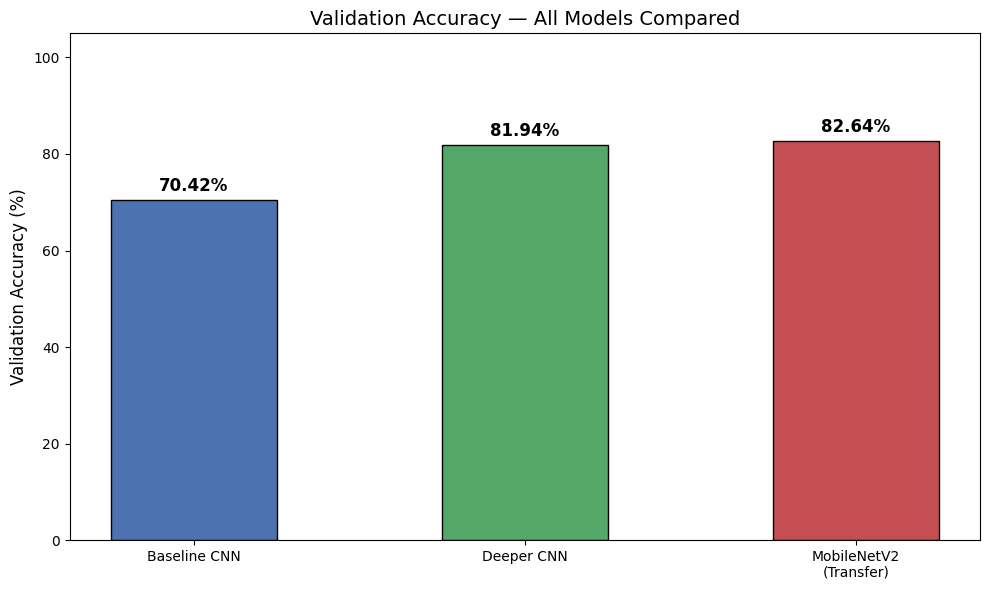

In [ ]:
# STEP 15: Final Evaluation — All Models Compared
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ── Evaluate all models on validation set ─────────────────
print("Evaluating all models...\n")

# Reload generators
_, val_gen_64 = get_generators()

tl_val_gen = tl_val_datagen.flow_from_directory(
    train_dir, target_size=(96,96), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    subset='validation', shuffle=False, seed=42
)

# Baseline
from tensorflow.keras.models import load_model
baseline_model = load_model('/content/baseline_best_model.keras')
val_gen_64.reset()
base_loss, base_acc = baseline_model.evaluate(val_gen_64, verbose=0)

# Deeper
deeper_model = load_model('/content/deeper_best_model.keras')
val_gen_64.reset()
deep_loss, deep_acc = deeper_model.evaluate(val_gen_64, verbose=0)

# Transfer Learning
tl_val_gen.reset()
tl_loss, tl_acc = tl_model.evaluate(tl_val_gen, verbose=0)

# ── Summary Table ──────────────────────────────────────────
print("\n" + "="*65)
print(f"{'FINAL MODEL COMPARISON':^65}")
print("="*65)
print(f"{'Model':<20} {'Val Acc':>10} {'Val Loss':>10} {'Train Time':>12}")
print("-"*65)
print(f"{'Baseline CNN':<20} {base_acc*100:>9.2f}% {base_loss:>10.4f} {'26.19 min':>12}")
print(f"{'Deeper CNN':<20} {deep_acc*100:>9.2f}% {deep_loss:>10.4f} {'93.96 min':>12}")
print(f"{'MobileNetV2 (TL)':<20} {tl_acc*100:>9.2f}% {tl_loss:>10.4f} {tl_total_time:>11.2f}m")
print("="*65)

# ── Bar Chart Comparison ───────────────────────────────────
models     = ['Baseline CNN', 'Deeper CNN', 'MobileNetV2\n(Transfer)']
accuracies = [base_acc*100, deep_acc*100, tl_acc*100]
colors     = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
plt.title('Validation Accuracy — All Models Compared', fontsize=14)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150)
plt.show()

Test images found: ['20180625_203333.jpg', '20180625_230047.jpg', '20180701_194331.jpg']


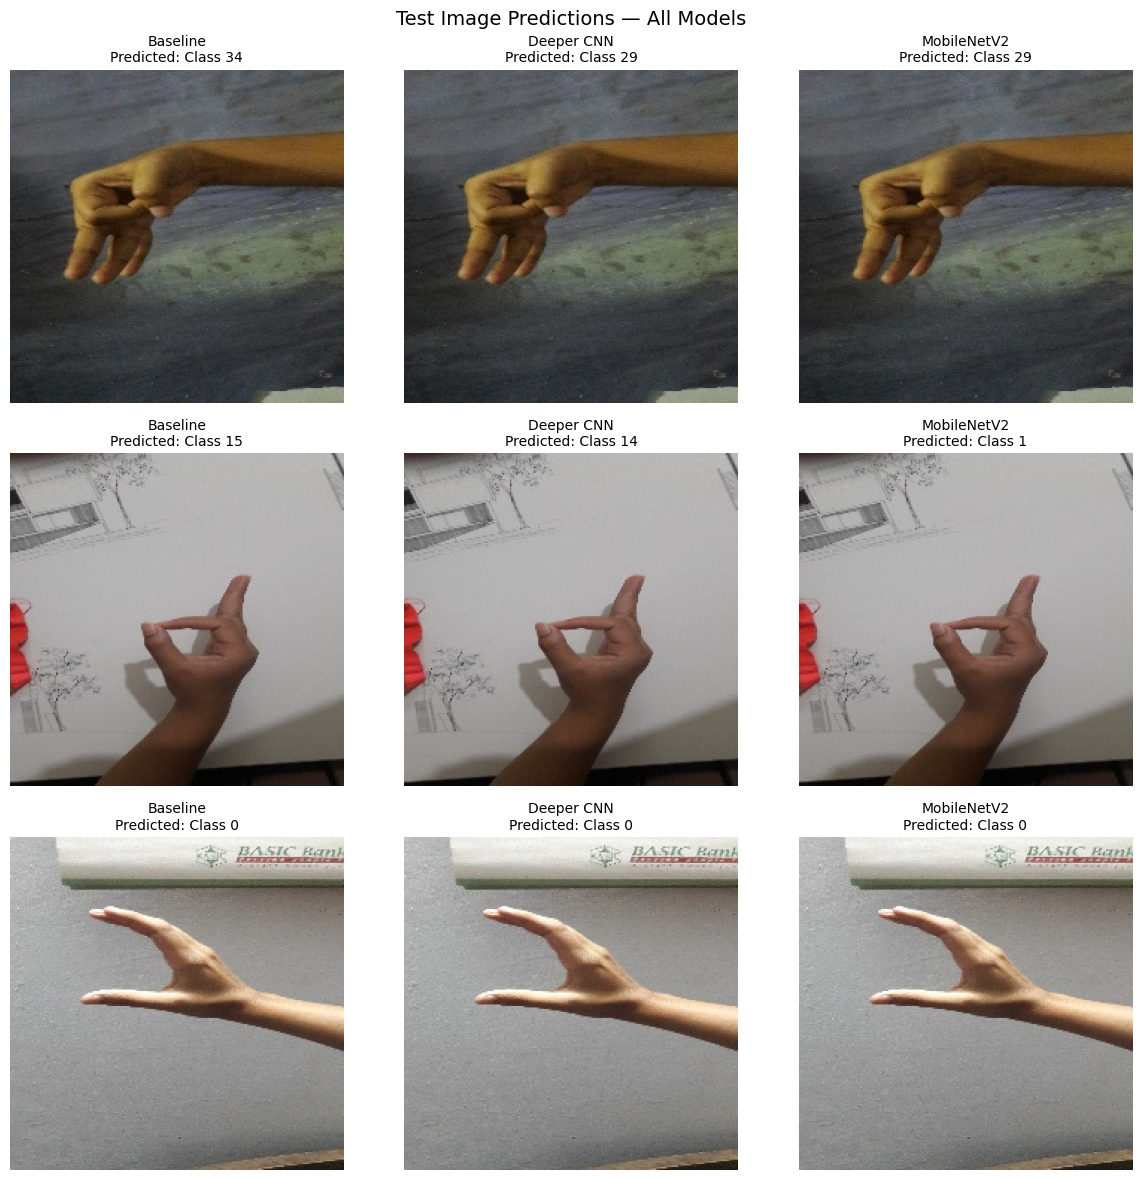


📋 Test Predictions Summary:
---------------------------------------------
Image                Baseline   Deeper       TL
---------------------------------------------
20180625_203333.jpg        34       29       29
20180625_230047.jpg        15       14        1
20180701_194331.jpg         0        0        0


In [ ]:
# STEP 16: Inference on Test Images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

test_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 2/Dataset/Test'
test_images = os.listdir(test_dir)
print(f"Test images found: {test_images}")

deeper_model = load_model('/content/deeper_best_model.keras')
tl_model_loaded = load_model('/content/tl_best_model.keras')

fig, axes = plt.subplots(len(test_images), 3, figsize=(12, 4*len(test_images)))
fig.suptitle('Test Image Predictions — All Models', fontsize=14)

if len(test_images) == 1:
    axes = [axes]

for i, img_file in enumerate(test_images):
    img_path = os.path.join(test_dir, img_file)

    # Load for 64x64 models
    img_64  = load_img(img_path, target_size=(64, 64))
    arr_64  = img_to_array(img_64) / 255.0
    arr_64  = np.expand_dims(arr_64, axis=0)

    # Load for 96x96 TL model
    img_96  = load_img(img_path, target_size=(96, 96))
    arr_96  = img_to_array(img_96) / 255.0
    arr_96  = np.expand_dims(arr_96, axis=0)

    # Predictions
    base_pred  = classes[np.argmax(baseline_model.predict(arr_64, verbose=0))]
    deep_pred  = classes[np.argmax(deeper_model.predict(arr_64, verbose=0))]
    tl_pred    = classes[np.argmax(tl_model_loaded.predict(arr_96, verbose=0))]

    # Display original image 3 times with each model's prediction
    original = mpimg.imread(img_path)
    for j, (pred, model_name) in enumerate([(base_pred, 'Baseline'),
                                             (deep_pred, 'Deeper CNN'),
                                             (tl_pred,   'MobileNetV2')]):
        axes[i][j].imshow(original)
        axes[i][j].set_title(f'{model_name}\nPredicted: Class {pred}', fontsize=10)
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150)
plt.show()

print("\n📋 Test Predictions Summary:")
print("-"*45)
print(f"{'Image':<20} {'Baseline':>8} {'Deeper':>8} {'TL':>8}")
print("-"*45)
for img_file in test_images:
    img_path = os.path.join(test_dir, img_file)
    img_64 = np.expand_dims(img_to_array(load_img(img_path, target_size=(64,64)))/255., 0)
    img_96 = np.expand_dims(img_to_array(load_img(img_path, target_size=(96,96)))/255., 0)
    b = classes[np.argmax(baseline_model.predict(img_64, verbose=0))]
    d = classes[np.argmax(deeper_model.predict(img_64, verbose=0))]
    t = classes[np.argmax(tl_model_loaded.predict(img_96, verbose=0))]
    print(f"{img_file:<20} {b:>8} {d:>8} {t:>8}")